# Fraud Detection EDA

In [1]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load the data
train = pd.read_csv(r"../data/fraudTrain.csv")
test = pd.read_csv(r"../data/fraudTest.csv")

In [3]:
#information of Training data
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

In [4]:
#information of Testing data
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  str    
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  str    
 4   category               555719 non-null  str    
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  str    
 7   last                   555719 non-null  str    
 8   gender                 555719 non-null  str    
 9   street                 555719 non-null  str    
 10  city                   555719 non-null  str    
 11  state                  555719 non-null  str    
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-null  float64

In [5]:
#check nan values in train data
train.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [6]:
#check nan values in test data
test.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

### Feature Selection

In [3]:
def feature_engineering(df):
    #convert to datetime column
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
    df["dob"] = pd.to_datetime(df["dob"])

    #create age column
    df["age"] = df["trans_date_trans_time"].dt.year - df["dob"].dt.year

    #extract time features
    df["hour"] = df["trans_date_trans_time"].dt.hour
    df["day"] = df["trans_date_trans_time"].dt.day

    #Distance calculation
    df["distance"] = np.sqrt(
                            (df["lat"]-df["merch_lat"])**2 + 
                             (df["long"]-df["merch_long"])**2
                             )
    
    return df


train = feature_engineering(train)
test = feature_engineering(test)

In [4]:
#Select useful columns

def feature_extraction(df):
    #select required columns
    selected_cols = ['hour', 'day','category', 'amt',
            'gender', 'state',
        'distance','city_pop', 'age', 'is_fraud']
    
    df = df.loc[:,selected_cols]
    return df


train = feature_extraction(train)
test = feature_extraction(test)

In [5]:
def data_label(a):
    for i in a.containers:
        a.bar_label(i)

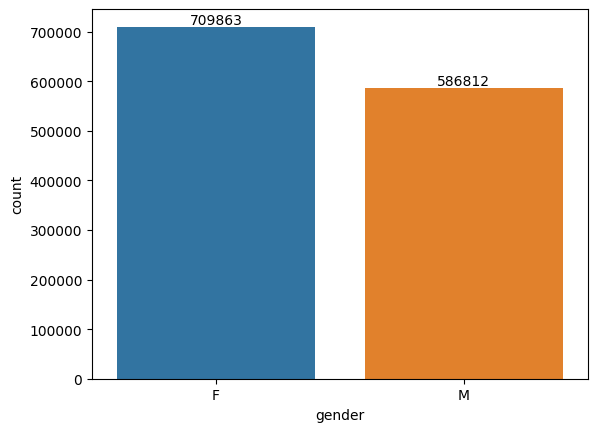

In [10]:
a = sns.countplot(x="gender",data=train,hue="gender")
data_label(a)

most of the transactions has done by females.

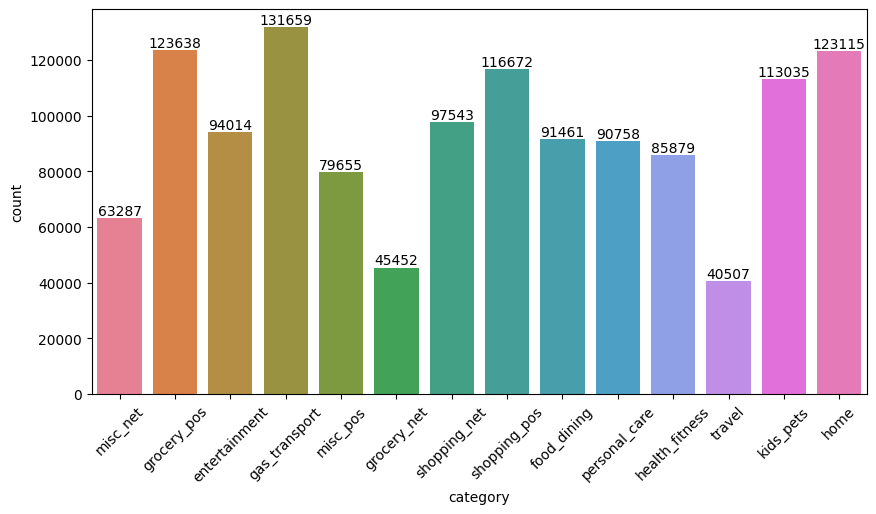

In [11]:
plt.figure(figsize=(10,5))
a = sns.countplot(x="category",data=train,hue="category")
plt.xticks(rotation=45)
data_label(a)
plt.show()

<Axes: xlabel='amt', ylabel='Count'>

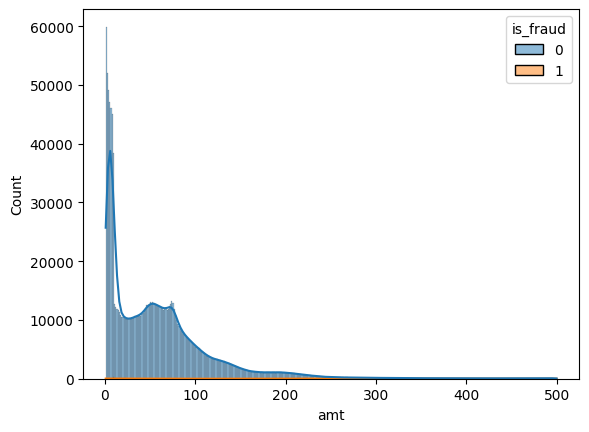

In [12]:
sns.histplot(x="amt",data=train[train["amt"]<500],kde=True,hue="is_fraud")

Most transactions had done between $1 to $100

<Axes: xlabel='is_fraud', ylabel='count'>

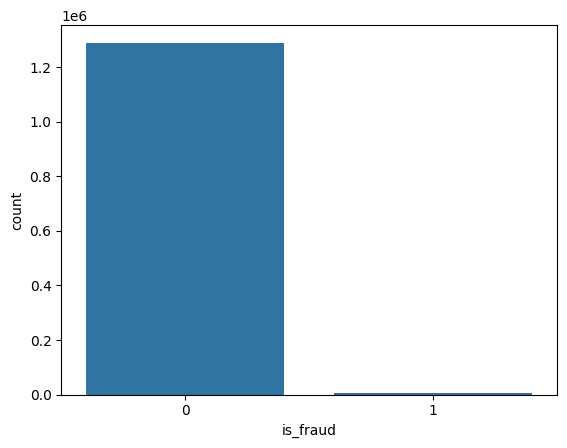

In [13]:
sns.countplot(x="is_fraud",data=train)

This dataset is highly imbalanced

Model Training and Evaluation

In [6]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [7]:
#Divide the data into input and output features
X_train = train.drop("is_fraud",axis=1)
y_train = train.is_fraud

X_test = test.drop("is_fraud",axis=1)
y_test = test.is_fraud

In [14]:
X_test

,hour,day,category,amt,gender,state,distance,city_pop,age
0,12,21,personal_care,2.86,M,SC,0.266004,333497,52
1,12,21,personal_care,29.84,F,UT,0.991674,302,30
2,12,21,health_fitness,41.28,F,NY,0.682970,34496,50
3,12,21,misc_pos,60.05,M,FL,0.250985,54767,33
4,12,21,travel,3.19,M,MI,1.118816,1126,65
...,...,...,...,...,...,...,...,...,...
555714,23,31,health_fitness,43.77,M,MO,0.780782,519,54
555715,23,31,kids_pets,111.84,M,TX,0.971537,28739,21
555716,23,31,kids_pets,86.88,F,WA,0.935280,3684,39
555717,23,31,travel,7.99,M,ID,0.650323,129,55


In [21]:
#Divide numerical and categorical columns
numeric_cols = X_train.select_dtypes(include=["int32","int64","float64"]).columns
cat_cols = X_train.select_dtypes(include=["str"]).columns

In [22]:
#Preprocessing pipeline
preprocessor = ColumnTransformer([
    ("scaler",StandardScaler(),numeric_cols),
    ("encoder",OneHotEncoder(handle_unknown="ignore"),cat_cols)
])

In [29]:
#Model pipeline
pipe = Pipeline([
    ("preprocessor",preprocessor),
    ("model",XGBClassifier(n_estimators=50, max_depth=6,random_state=42,tree_method="hist"))
])

pipe.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. T

In [30]:
#Prediction
ypred = pipe.predict(X_test)

In [31]:
#model evaluation
from sklearn.metrics import classification_report
print(classification_report(y_test,ypred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.89      0.77      0.83      2145

    accuracy                           1.00    555719
   macro avg       0.94      0.89      0.91    555719
weighted avg       1.00      1.00      1.00    555719



In [33]:
#save the model
import joblib
joblib.dump(pipe,r"../models/xgb_pipeline.pkl")

['../models/xgb_pipeline.pkl']

In [35]:
#save the preprocessed data
train.to_csv(r"../data/preprocessed_fraudTrain.csv")
test.to_csv(r"../data/preprocessed_fraudTest.csv")